# 04 EDA: shapes, relationships and the checks the R models depend on

Exploratory analysis of `analytic_cohort.parquet`. Like notebook 03, everything here is **crude and
unweighted**: it describes the sample, not the US population. The point is not headline numbers but
decisions for the R models in notebooks 05 to 09:

| Question | Section | Decision it feeds |
|---|---|---|
| Which measures are skewed? | 1 | Log-transform before modelling |
| Did the sample mix change across cycles? | 3 | Whether the 2007 prevalence jump is composition or measurement |
| Which biomarkers carry the same information? | 4 | Which one to keep in a model |
| Is missing data random? | 5 | Whether multiple imputation is needed |
| Is risk a straight line or a curve? | 6 | Splines vs linear terms |
| How much does age distort crude comparisons? | 7 | Age adjustment everywhere |

Figures go to `outputs/figures/04_*.png`, tables to `outputs/tables/04_*.csv`.

In [1]:
import pandas as pd, numpy as np, pathlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = pathlib.Path("/content/drive/MyDrive/NHANES Cardiometabolic Mortality Project")
except ImportError:
    ROOT = pathlib.Path.cwd().parent

assert (ROOT / "notebooks").exists(), f"Project folder not found at {ROOT}"
FIG_DIR, TAB_DIR, SQL_DIR = ROOT / "outputs" / "figures", ROOT / "outputs" / "tables", ROOT / "outputs" / "sql_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
coh = pd.read_parquet(ROOT / "data" / "processed" / "analytic_cohort.parquet")
assert coh.groupby("cycle").egfr.apply(lambda s: s.notna().mean()).min() > 0.5, "eGFR missing for a whole cycle: re-run the latest notebook 02 first"
coh.shape

Mounted at /content/drive


(50819, 58)

### Chart style

One style for every figure: a light surface, recessive grid, thin marks. Colors come from a
palette checked for colour-blind separation. Glycemic status always uses the same three colours
(normal blue, prediabetes orange, diabetes green), so a reader can move between charts without re-learning them.

In [2]:
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e1e0d9", "#fcfcfb"
S1, S2, S3, S4, S5, NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#a8a69f"
GLY = {"normal": S1, "prediabetes": S2, "diabetes": S3}
DIVERGING = LinearSegmentedColormap.from_list("div", ["#256abf", "#f0efec", "#c2412f"])
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9.5, "lines.linewidth": 2,
                     "legend.frameon": False})

def save(fig, name):
    fig.savefig(FIG_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rates(df, by):
    a = df.groupby(by, observed=True).agg(n=("SEQN", "size"), deaths=("death", "sum"), py=("time_months", lambda s: s.sum() / 12))
    return a.assign(rate=1000 * a.deaths / a.py)

def crude_vs_std(df, by):
    strat = rates(df, [by, "age_group"]).rate.unstack()
    w = df.age_group.value_counts(normalize=True).reindex(strat.columns)
    return rates(df, by).assign(age_std_rate=(strat * w).sum(axis=1, min_count=1) / strat.notna().mul(w).sum(axis=1)).round(2)

**Age-standardized rate:** each group's age-specific death rates, re-weighted to the age mix of the
whole cohort. It answers "what would this group's death rate be if it had the same ages as everyone
else?", which removes most of the age distortion seen in notebook 03.

## 1. Distributions of the continuous measures

Skewness above 1 (long right tail) means a log transform will usually give the models a better fit
and stop a few extreme values from dominating.

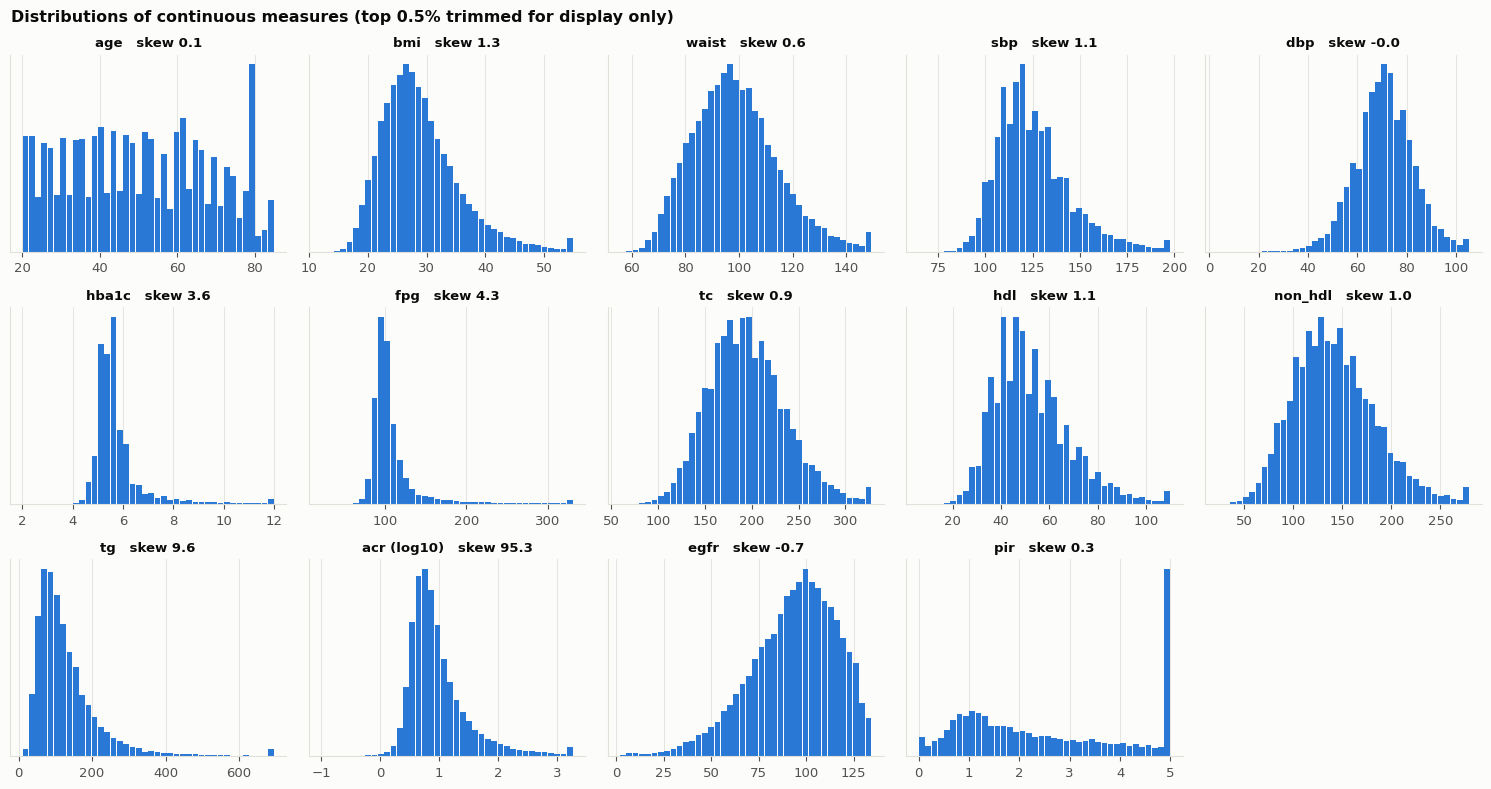

,n,median,p1,p99,skewness,skewness_log,log_transform
age,50819,50.00,20.00,85.00,0.10,-0.44,False
bmi,49782,27.87,17.90,50.70,1.32,0.41,True
waist,47884,97.50,68.60,144.00,0.58,0.10,False
sbp,48485,122.00,92.67,187.33,1.10,0.56,True
dbp,48249,71.33,42.00,100.67,-0.01,-1.31,False
hba1c,48283,5.50,4.50,10.90,3.62,2.38,True
fpg,23357,100.00,75.00,291.00,4.32,2.35,True
tc,47699,192.00,112.00,310.00,0.86,-0.12,False
hdl,47697,50.00,26.00,101.00,1.12,0.06,True
non_hdl,47696,139.00,62.00,260.00,0.96,-0.32,False


In [3]:
CONT = ["age", "bmi", "waist", "sbp", "dbp", "hba1c", "fpg", "tc", "hdl", "non_hdl", "tg", "acr", "egfr", "pir"]
skew = pd.DataFrame({"n": coh[CONT].notna().sum(), "median": coh[CONT].median(), "p1": coh[CONT].quantile(.01), "p99": coh[CONT].quantile(.99),
                     "skewness": coh[CONT].skew(), "skewness_log": np.log(coh[CONT].clip(lower=0.01)).skew()}).round(2)
skew["log_transform"] = (skew.skewness.abs() > 1) & (skew.skewness_log.abs() < skew.skewness.abs())
skew.to_csv(TAB_DIR / "04_skewness.csv")

fig, axes = plt.subplots(3, 5, figsize=(15, 8))
for ax, v in zip(axes.flat, CONT):
    x = coh[v].dropna().clip(upper=coh[v].quantile(.995))
    ax.hist(np.log10(x.clip(lower=0.01)) if v == "acr" else x, bins=40, color=S1, rwidth=0.9)
    ax.set_title(f"{v}{' (log10)' if v == 'acr' else ''}   skew {skew.loc[v, 'skewness']:.1f}", fontsize=9.5)
    ax.set_yticks([])
axes.flat[-1].axis("off")
fig.suptitle("Distributions of continuous measures (top 0.5% trimmed for display only)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "distributions")
skew

## 2. Who is in the cohort

In [4]:
CATS = ["sex_lbl", "age_group", "race_eth_lbl", "education_lbl", "smoking", "bmi_cat", "glycemic_status"]
composition = pd.concat({c: coh[c].value_counts(dropna=False).rename_axis("level").to_frame("n").assign(pct=lambda f: (100 * f.n / len(coh)).round(1)) for c in CATS})
composition.to_csv(TAB_DIR / "04_composition.csv")
composition

n   pct
                level                          
sex_lbl         female              25667  50.5
                male                25152  49.5
age_group       20-39               16519  32.5
                40-59               16505  32.5
                60-79               14098  27.7
                80+                  3697   7.3
race_eth_lbl    Non-Hispanic White  22358  44.0
                Non-Hispanic Black  10799  21.2
                Mexican American     8773  17.3
                Other/Multiracial    4703   9.3
                Other Hispanic       4186   8.2
education_lbl   >HS                 25048  49.3
                <HS                 13898  27.3
                HS/GED              11792  23.2
                NaN                    81   0.2
smoking         never               27395  53.9
                former              12592  24.8
                current             10781  21.2
                NaN                    51   0.1
bmi_cat         obese               18117  35.7
                overweight          16807  33.1
                normal              14042  27.6
                NaN                  1037   2.0
                underweight           816   1.6
glycemic_status normal              24885  49.0
                prediabetes         15175  29.9
                diabetes             8575  16.9
                NaN                  2184   4.3

## 3. Did the sample change between cycles?

In notebook 03, prediabetes jumped from about 28% to 35% between 2005-06 and 2007-08, and mean
HbA1c rose with it. Two possible reasons:

1. **Composition:** from 2007, NHANES oversampled all Hispanic adults (not just Mexican American),
   and from 2011 Asian adults. Crude numbers don't undo oversampling; survey weights do.
2. **Measurement:** a change in the HbA1c lab or method.

The test: if the jump also appears **within a single race/ethnicity group**, composition can't
explain it.

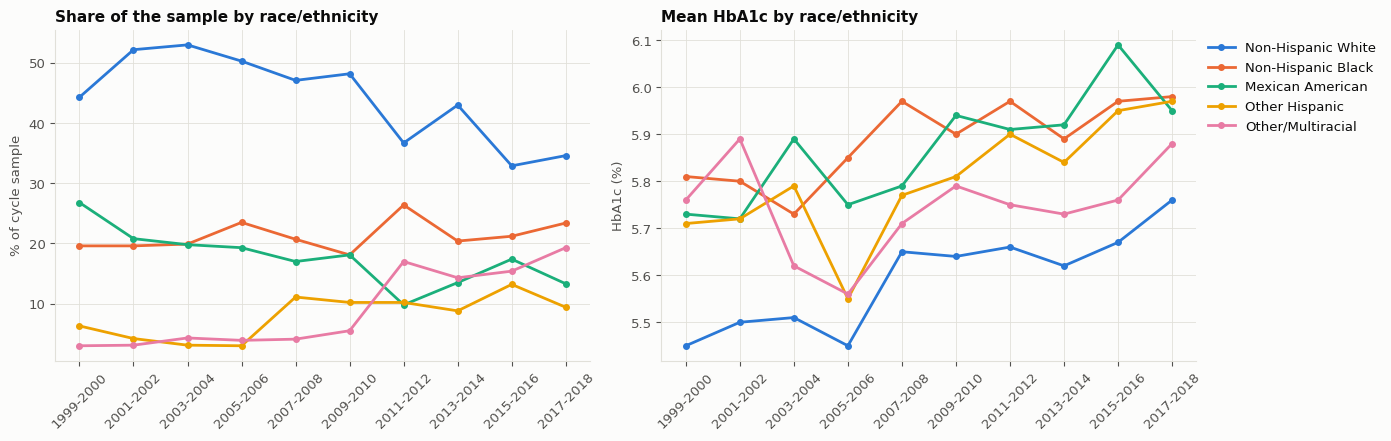

race_eth_lbl,Mexican American,Non-Hispanic Black,Non-Hispanic White,Other Hispanic,Other/Multiracial
cycle,,,,,
1999-2000,26.8,19.6,44.3,6.3,3.0
2001-2002,20.8,19.6,52.2,4.2,3.1
2003-2004,19.8,19.9,53.0,3.1,4.3
2005-2006,19.3,23.5,50.3,3.0,3.9
2007-2008,17.0,20.7,47.1,11.1,4.1
2009-2010,18.1,18.1,48.2,10.2,5.5
2011-2012,9.8,26.4,36.7,10.2,17.0
2013-2014,13.5,20.4,43.0,8.8,14.3
2015-2016,17.4,21.2,32.9,13.2,15.4


race_eth_lbl,Mexican American,Non-Hispanic Black,Non-Hispanic White,Other Hispanic,Other/Multiracial
cycle,,,,,
1999-2000,5.73,5.81,5.45,5.71,5.76
2001-2002,5.72,5.80,5.50,5.72,5.89
2003-2004,5.89,5.73,5.51,5.79,5.62
2005-2006,5.75,5.85,5.45,5.55,5.56
2007-2008,5.79,5.97,5.65,5.77,5.71
2009-2010,5.94,5.90,5.64,5.81,5.79
2011-2012,5.91,5.97,5.66,5.90,5.75
2013-2014,5.92,5.89,5.62,5.84,5.73
2015-2016,6.09,5.97,5.67,5.95,5.76


In [5]:
mix = pd.crosstab(coh.cycle, coh.race_eth_lbl, normalize="index").mul(100).round(1)
hba1c_by_race = coh.pivot_table(index="cycle", columns="race_eth_lbl", values="hba1c", aggfunc="mean").round(2)
mix.to_csv(TAB_DIR / "04_race_mix_by_cycle.csv"); hba1c_by_race.to_csv(TAB_DIR / "04_hba1c_by_cycle_race.csv")

RACE_COL = dict(zip(["Non-Hispanic White", "Non-Hispanic Black", "Mexican American", "Other Hispanic", "Other/Multiracial"], [S1, S2, S3, S4, S5]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tbl, title, unit in [(axes[0], mix, "Share of the sample by race/ethnicity", "% of cycle sample"), (axes[1], hba1c_by_race, "Mean HbA1c by race/ethnicity", "HbA1c (%)")]:
    for race in RACE_COL:
        if race in tbl:
            ax.plot(tbl.index, tbl[race], color=RACE_COL[race], marker="o", ms=4, label=race)
    ax.set_title(title, loc="left"); ax.set_ylabel(unit); ax.tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
save(fig, "cycle_composition_hba1c")
display(mix)
hba1c_by_race

**How to read this:** if the left panel shows the Hispanic share rising in 2007-08 while the right
panel's lines stay flat within each group, the jump is composition and the survey weights in R fix
it. If every group's HbA1c line steps up at the same cycle, it's measurement, and the R models
should include survey cycle as a covariate (or a sensitivity analysis restricted to one lab period).

## 4. Which biomarkers overlap?

Spearman correlation (rank-based, robust to skew). Pairs above 0.7 carry largely the same
information, and putting both in one model makes their coefficients unstable. Some overlaps are
built in: `non_hdl` is `tc` minus `hdl`, and `egfr` is computed from creatinine and age.

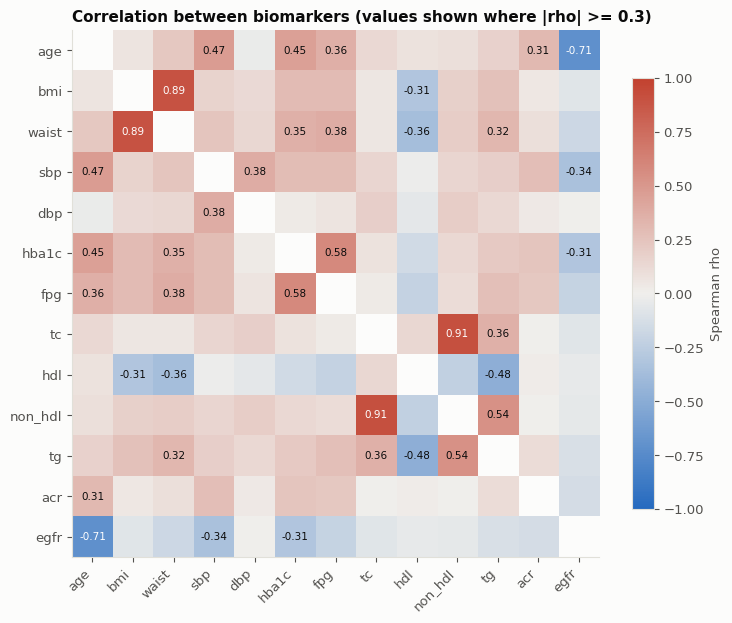

,var_1,var_2,rho
64,tc,non_hdl,0.91
12,bmi,waist,0.89
11,age,egfr,-0.71


In [6]:
BIO = ["age", "bmi", "waist", "sbp", "dbp", "hba1c", "fpg", "tc", "hdl", "non_hdl", "tg", "acr", "egfr"]
rho = coh[BIO].corr(method="spearman")
pairs = rho.where(np.triu(np.ones(rho.shape, bool), 1)).stack().rename_axis(["var_1", "var_2"]).rename("rho").reset_index()
high = pairs[pairs.rho.abs() >= 0.7].sort_values("rho", key=abs, ascending=False).round(2)
rho.round(3).to_csv(TAB_DIR / "04_spearman.csv"); high.to_csv(TAB_DIR / "04_high_correlation_pairs.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(rho.mask(np.eye(len(BIO), dtype=bool)), cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(BIO)), BIO, rotation=45, ha="right"); ax.set_yticks(range(len(BIO)), BIO); ax.grid(False)
for i in range(len(BIO)):
    for j in range(len(BIO)):
        if i != j and abs(rho.iat[i, j]) >= 0.3:
            ax.text(j, i, f"{rho.iat[i, j]:.2f}", ha="center", va="center", fontsize=7.5, color="white" if abs(rho.iat[i, j]) >= 0.6 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho")
ax.set_title("Correlation between biomarkers (values shown where |rho| >= 0.3)", loc="left")
save(fig, "correlation")
high

## 5. Is missing data random?

For every variable with missing values: are the people missing it older, or more likely to die,
than the people with a value? If yes, dropping them (complete-case analysis) would bias the
results toward healthier people, and multiple imputation in R is required. Fasting-only measures
(`fpg`, `tg`, `ldl`) are left out because they are missing by design.

In [7]:
rate = lambda g: 1000 * g.death.sum() / (g.time_months.sum() / 12)
MISS = [v for v in ["education", "pir", "bmi", "waist", "sbp", "hba1c", "tc", "hdl", "acr", "egfr", "smoking"] if coh[v].isna().any()]
missing_vs_outcome = pd.DataFrame([{"variable": v, "n_missing": int(m.sum()), "pct_missing": 100 * m.mean(),
                                     "mean_age_missing": coh.age[m].mean(), "mean_age_observed": coh.age[~m].mean(),
                                     "death_rate_missing": rate(coh[m]), "death_rate_observed": rate(coh[~m])}
                                    for v in MISS for m in [coh[v].isna()]]).set_index("variable").round(1)
missing_vs_outcome["rate_ratio"] = (missing_vs_outcome.death_rate_missing / missing_vs_outcome.death_rate_observed).round(2)
missing_vs_outcome.to_csv(TAB_DIR / "04_missing_vs_outcome.csv")
missing_vs_outcome.sort_values("rate_ratio", ascending=False)

,n_missing,pct_missing,mean_age_missing,mean_age_observed,death_rate_missing,death_rate_observed,rate_ratio
variable,,,,,,,
bmi,1037,2.0,60.6,50.1,62.2,16.5,3.77
education,81,0.2,64.6,50.3,59.5,17.2,3.46
acr,1363,2.7,57.0,50.1,53.2,16.4,3.24
waist,2935,5.8,57.3,49.8,46.4,15.9,2.92
smoking,51,0.1,57.8,50.3,27.9,17.2,1.62
hdl,3122,6.1,50.4,50.3,25.5,16.7,1.53
tc,3120,6.1,50.4,50.3,25.4,16.7,1.52
egfr,3248,6.4,50.5,50.3,25.1,16.7,1.50
hba1c,2536,5.0,49.0,50.3,24.6,16.9,1.46


A `rate_ratio` well above 1 means people missing that value die at a higher rate than people who
have it. That's the signature of data that are *not* missing completely at random.

## 6. Is the risk a straight line or a curve?

Death rate by tenth (decile) of each measure, crude (grey) and age-standardized (blue). The
crude line mostly tracks age. The age-standardized line is the fairer shape. A U or J shape (high
risk at both ends) means a linear model term would be wrong and the R models need splines.

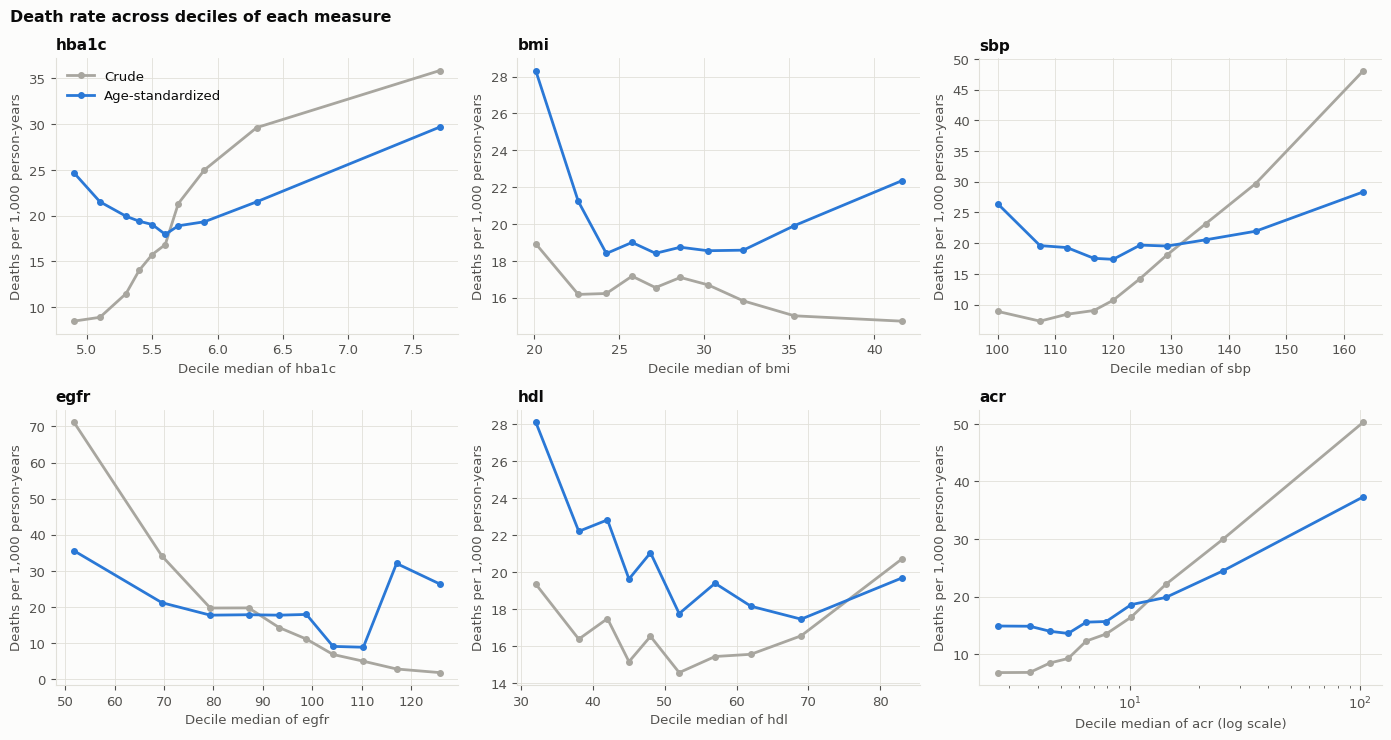

In [8]:
SHAPE = ["hba1c", "bmi", "sbp", "egfr", "hdl", "acr"]
curves = []
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, v in zip(axes.flat, SHAPE):
    sub = coh.dropna(subset=[v]).assign(decile=lambda f: pd.qcut(f[v], 10, labels=False, duplicates="drop"))
    cv = crude_vs_std(sub, "decile").join(sub.groupby("decile")[v].median().rename("median_value"))
    curves.append(cv.assign(variable=v))
    ax.plot(cv.median_value, cv.rate, color=NEUTRAL, marker="o", ms=4, label="Crude")
    ax.plot(cv.median_value, cv.age_std_rate, color=S1, marker="o", ms=4, label="Age-standardized")
    ax.set_title(v, loc="left"); ax.set_ylabel("Deaths per 1,000 person-years")
    if v == "acr": ax.set_xscale("log")
    ax.set_xlabel(f"Decile median of {v}{' (log scale)' if v == 'acr' else ''}")
axes.flat[0].legend(loc="upper left")
fig.suptitle("Death rate across deciles of each measure", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "risk_shape_by_decile")
pd.concat(curves).round(2).to_csv(TAB_DIR / "04_risk_by_decile.csv")

## 7. How much does age distort the crude comparisons?

Crude and age-standardized death rates side by side for the groupings used in notebook 03. Where
the two differ a lot, the crude number from notebook 03 was mostly telling you about age. This also
explains why the obesity-only group looked *safer* than "none of the four" there: people with
obesity alone are younger on average.

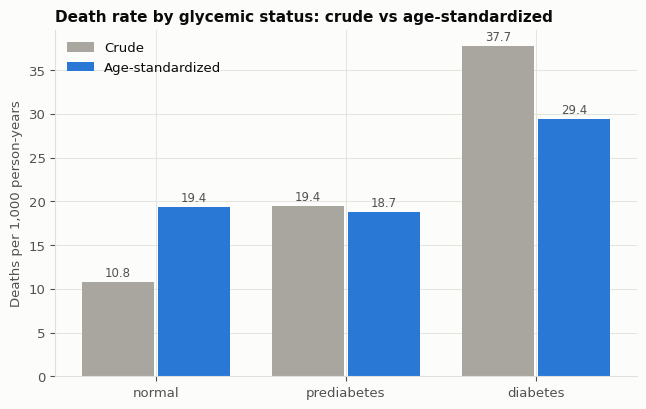

n  deaths         py   rate  age_std_rate  \
                level                                                        
glycemic_status diabetes      8575  2520.0   66785.17  37.73         29.39   
                normal       24885  2808.0  261044.58  10.76         19.38   
                prediabetes  15175  2555.0  131555.83  19.42         18.73   
n_conditions    0.0          18540  1380.0  192622.33   7.16         16.64   
                1.0          16053  2927.0  148332.75  19.73         19.59   
                2.0           8544  2051.0   73222.75  28.01         23.30   
                3.0           3280   880.0   25647.08  34.31         28.36   
bmi_cat         underweight    816   183.0    7307.50  25.04         39.11   
                normal       14042  2271.0  136071.08  16.69         21.88   
                overweight   16807  2736.0  162373.42  16.85         19.00   
                obese        18117  2574.0  165943.75  15.51         20.23   
smoking         current      10781  1692.0  106465.17  15.89         31.87   
                former       12592  3214.0  114091.17  28.17         23.13   
                never        27395  3358.0  258877.58  12.97         16.93   
sex_lbl         female       25667  3687.0  244705.92  15.07         17.87   
                male         25152  4592.0  235265.42  19.52         24.96   

                             crude_to_std_ratio  
                level                            
glycemic_status diabetes                   1.28  
                normal                     0.56  
                prediabetes                1.04  
n_conditions    0.0                        0.43  
                1.0                        1.01  
                2.0                        1.20  
                3.0                        1.21  
bmi_cat         underweight                0.64  
                normal                     0.76  
                overweight                 0.89  
                obese                      0.77  
smoking         current                    0.50  
                former                     1.22  
                never                      0.77  
sex_lbl         female                     0.84  
                male                       0.78

In [9]:
coh_c = coh.assign(n_conditions=(coh.diabetes + coh.hypertension + coh.bmi.ge(30)).where(coh[["diabetes", "hypertension", "bmi"]].notna().all(axis=1)))
age_adjusted = pd.concat({g: crude_vs_std(coh_c, g).rename_axis("level") for g in ["glycemic_status", "n_conditions", "bmi_cat", "smoking", "sex_lbl"]})
age_adjusted["crude_to_std_ratio"] = (age_adjusted.rate / age_adjusted.age_std_rate).round(2)
age_adjusted.to_csv(TAB_DIR / "04_crude_vs_age_standardized.csv")

g = age_adjusted.loc["glycemic_status"].reindex(["normal", "prediabetes", "diabetes"])
x, w = np.arange(len(g)), 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for off, col, colr, lbl in [(-w / 2 - 0.01, "rate", NEUTRAL, "Crude"), (w / 2 + 0.01, "age_std_rate", S1, "Age-standardized")]:
    bars = ax.bar(x + off, g[col], w, color=colr, label=lbl)
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8.5, color=INK2)
ax.set_xticks(x, g.index); ax.set_ylabel("Deaths per 1,000 person-years"); ax.legend(loc="upper left")
ax.set_title("Death rate by glycemic status: crude vs age-standardized", loc="left")
save(fig, "glycemic_crude_vs_std")
age_adjusted

## 8. Survival by glycemic status

The actuarial life table from notebook 03, drawn as survival curves. These are crude. Weighted
Kaplan-Meier curves and Cox models with confidence intervals come in R.

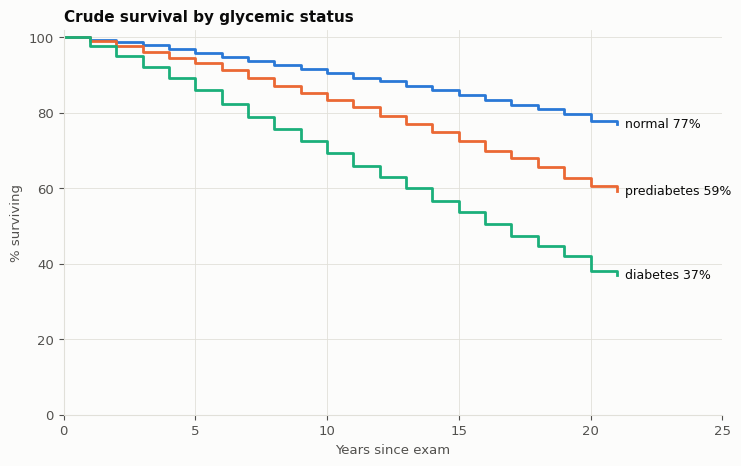

In [10]:
life = pd.read_csv(SQL_DIR / "q11_life_table.csv")
fig, ax = plt.subplots(figsize=(8.5, 5))
ends = []
for status, colr in GLY.items():
    s = life[life.glycemic_status == status]
    ax.step(np.r_[0, s.fu_year + 1], np.r_[100, s.pct_surviving], where="post", color=colr)
    ends.append([s.pct_surviving.iloc[-1], s.pct_surviving.iloc[-1], s.fu_year.iloc[-1] + 1, status])
ends.sort()
for i in range(1, len(ends)):
    ends[i][1] = max(ends[i][1], ends[i - 1][1] + 5)
for val, ypos, xpos, status in ends:
    ax.annotate(f"{status} {val:.0f}%", (xpos, ypos), xytext=(6, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
ax.set_xlabel("Years since exam"); ax.set_ylabel("% surviving"); ax.set_ylim(0, 102); ax.set_xlim(0, life.fu_year.max() + 5)
ax.set_title("Crude survival by glycemic status", loc="left")
save(fig, "survival_by_glycemic")

## What this hands to R

Read these tables before writing the R models:

- `04_skewness.csv`: variables flagged `log_transform = True` enter the models on the log scale.
- `04_race_mix_by_cycle.csv` and `04_hba1c_by_cycle_race.csv`: decide whether survey cycle needs to be a covariate.
- `04_high_correlation_pairs.csv`: from each highly correlated pair, keep the more clinically standard one.
- `04_missing_vs_outcome.csv`: rate ratios away from 1 confirm multiple imputation over complete-case analysis.
- `04_risk_by_decile.csv`: U or J shapes get restricted cubic splines; roughly straight lines can stay linear.
- `04_crude_vs_age_standardized.csv`: the size of the age distortion, useful for the report's explanation of adjustment.


